In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, f_oneway

genotypes = pd.read_excel('genotypes.xls', header=1)
phenotypes = pd.read_excel('phenotypes.xls')


In [ ]:
# Q1

CHOSEN_PHENOTYPE_ID = 656
CHOSEN_SNP_ID = 96
B = 0
D = 1
H = 0.5

# chosen phenotype
chosen_phenotype_info = phenotypes[phenotypes['ID_FOR_CHECK'] == CHOSEN_PHENOTYPE_ID]
chosen_phenotype_info = chosen_phenotype_info.dropna(axis=1)
joint_columns = chosen_phenotype_info.columns.intersection(genotypes.columns)
chosen_phenotype_data = chosen_phenotype_info[joint_columns]
genotypes_data = genotypes[joint_columns].copy()

def get_chosen_genotype_data(chosen_SNP_data):
  chosen_SNP_data = chosen_SNP_data.dropna(axis=1)
  chosen_SNP_data = chosen_SNP_data.loc[:, chosen_SNP_data.iloc[0].isin(['B', 'D', 'H'])]  # removing "U" for unknown
  homozegous_data = chosen_SNP_data.loc[:, chosen_SNP_data.iloc[0].isin(['B', 'D'])]  # removing "H" for heterogenous
  return homozegous_data, chosen_SNP_data

def linear_regression(phenotype_data, SNP_data, plot=False):
  joint_columns = phenotype_data.columns.intersection(SNP_data.columns)
  phenotype_data = phenotype_data[joint_columns]
  SNP_data = SNP_data[joint_columns]
  x = SNP_data.iloc[0].map({"B": B, "D": D, "H": H})
  y = phenotype_data.iloc[0]
  res = linregress(x, y)
  if plot:
    plot_lin_regression_results(x, y, res)
  return res


def plot_lin_regression_results(x, y, results):
  x_axis = np.array([B, H, D]) if "H" in x.unique() else np.array([B, D])
  x_axis_names = ["B", "H", "D"] if "H" in x.unique() else ["B", "D"]
  y_axis = results.intercept + results.slope * x_axis

  plt.figure(figsize=(6, 4))

  plt.scatter(x, y, alpha=0.7, label="Strains")
  plt.plot(x_axis, y_axis, linewidth=2, label="Linear regression")
  plt.xticks(x_axis, x_axis_names)
  plt.xlabel("Genotype")
  plt.ylabel("Phenotype")
  plt.title(f"Regression: p={results.pvalue:.3g}, R²={results.rvalue**2:.3f}, slope={results.slope:.3f}")
  plt.legend()
  plt.tight_layout()
  plt.show()

def anova_test(phenotype_data, SNP_data):
  df = pd.DataFrame({
    "genotype": SNP_data.iloc[0],
    "phenotype": phenotype_data.iloc[0]
  }).dropna()
  B_phenotypes = df[df['genotype'] == 'B']['phenotype']
  #H_phenotypes = df[df['genotype'] == 'H']['phenotype']
  D_phenotypes = df[df['genotype'] == 'D']['phenotype']
  result = f_oneway(B_phenotypes, D_phenotypes)
  print('\n===== ANOVA test results =====')
  print(f'p-value: {result.pvalue}')
  print('==============================')

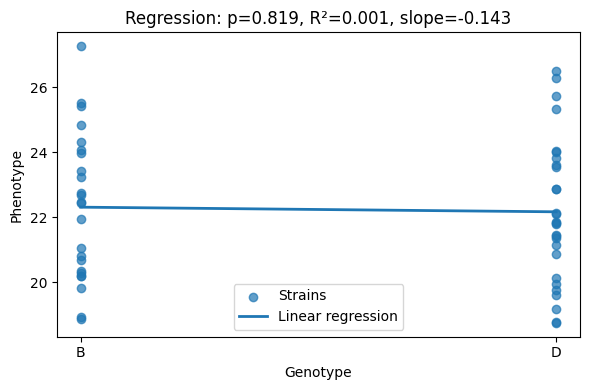

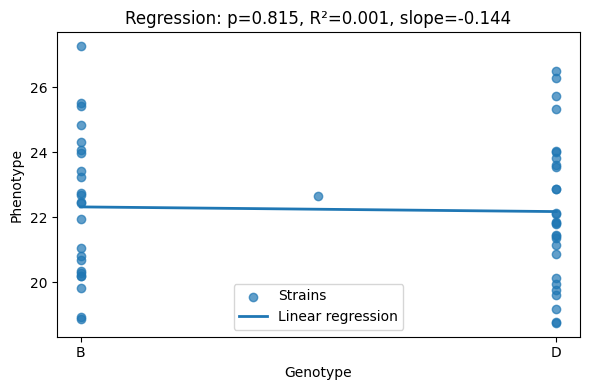


===== ANOVA test results =====
p-value: 0.8185394433012476


In [ ]:
chosen_SNP_info = genotypes_data[genotypes[0] == CHOSEN_SNP_ID]
homozegous_chosen_SNP_data, all_chosen_SNP_data = get_chosen_genotype_data(chosen_SNP_info)

# Q1.a
linear_regression(chosen_phenotype_data, homozegous_chosen_SNP_data, plot=True)

# Q1.b
linear_regression(chosen_phenotype_data, all_chosen_SNP_data, plot=True)

# Q1.c
anova_test(chosen_phenotype_data, homozegous_chosen_SNP_data)

In [ ]:
# Q2

def run_regression_for_SNP(SNP_data):
  return -np.log10(linear_regression(chosen_phenotype_data, pd.DataFrame(SNP_data).transpose(), plot=False).pvalue)

genotypes['-log(pvalue)'] = genotypes_data.apply(run_regression_for_SNP, axis=1)


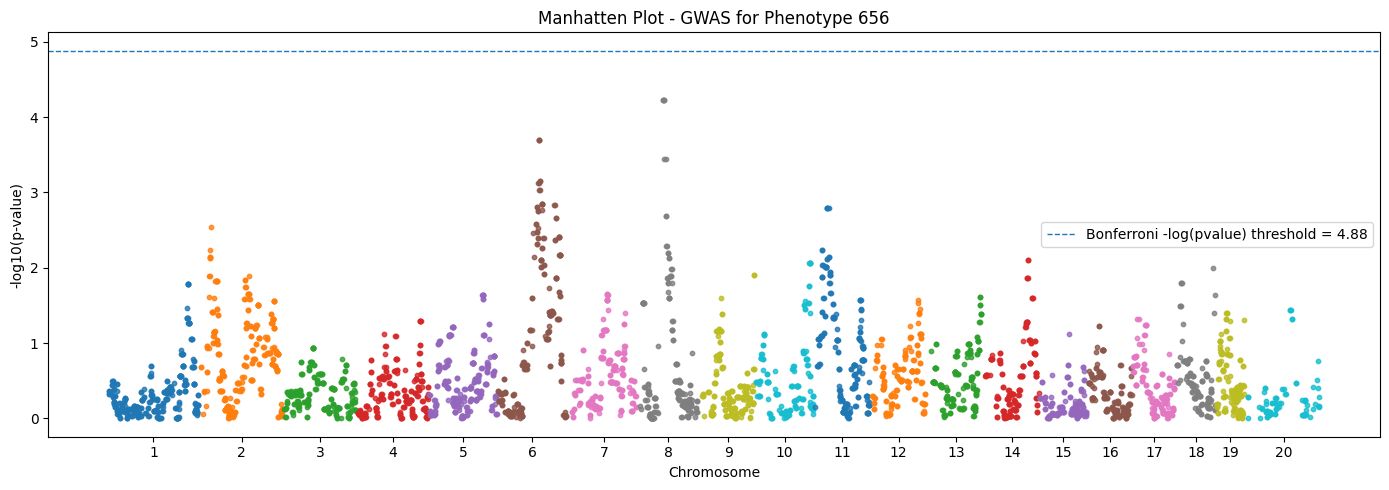

In [ ]:
results_to_submit = genotypes[[0, 'Locus', '-log(pvalue)']]
results_to_submit.to_csv('results.csv', index=False)

def plot_manhatten_plot(genotypes, minus_log_threshold_pval):
  # Build cumulative genomic position
    cumulative_offset = 0
    x_positions = []
    tick_positions = []
    tick_labels = []
    df = genotypes[['Chr_Build37', 'Build37_position', '-log(pvalue)']].copy()

    for chromosome, chromosome_data in df.groupby('Chr_Build37'):
      positions = chromosome_data['Build37_position'].values
      x = positions + cumulative_offset
      x_positions.extend(x)

      tick_positions.append((x.min() + x.max()) / 2)
      tick_labels.append(str(int(chromosome)))

      cumulative_offset = x.max()

    df["additive_position"] = x_positions

    # plot
    plt.figure(figsize=(14, 5))

    for chromosome, chromosome_data in df.groupby('Chr_Build37'):
      plt.scatter(
            chromosome_data["additive_position"],
            chromosome_data["-log(pvalue)"],
            s=10,
            alpha=0.8
        )

    plt.axhline(
      y=minus_log_threshold_pval,
      linestyle="--",
      linewidth=1,
      label=f"Bonferroni -log(pvalue) threshold = {minus_log_threshold_pval:.2f}"
    )

    plt.xticks(tick_positions, tick_labels)
    plt.xlabel("Chromosome")
    plt.ylabel("-log10(p-value)")
    plt.title(f"Manhatten Plot - GWAS for Phenotype {CHOSEN_PHENOTYPE_ID}")
    plt.legend()
    plt.tight_layout()
    plt.show()

threshold_pval = 0.05
n_genotypes = genotypes.shape[0]
fixed_threshold_pval = threshold_pval / n_genotypes
minus_log_threshold_pval = -np.log10(fixed_threshold_pval)

plot_manhatten_plot(genotypes, minus_log_threshold_pval=minus_log_threshold_pval)

In [ ]:
significant_SNPs = genotypes[genotypes['-log(pvalue)'] > minus_log_threshold_pval]
significant_SNPs = significant_SNPs[['Locus', 'Chr_Build37', 'Build37_position', '-log(pvalue)']].copy()
significant_SNPs#.loc[significant_SNPs.groupby('Chr_Build37')['-log(pvalue)'].idxmax()]

,Locus,Chr_Build37,Build37_position,-log(pvalue)
